In [1]:
import os
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from utils import *
from einops import rearrange

from matplotlib.colors import ListedColormap

with open(obs_labels_path, "rb") as f:
    data_dict = pickle.load(f)

setup_plot_style()

from scipy.stats import mode
from numpy.lib.stride_tricks import sliding_window_view

def rolling_mode_fast(labels, window_size):
    """Fast rolling mode using strided views."""
    # Pad to handle edges
    pad_width = window_size // 2
    padded = np.pad(labels, pad_width, mode='edge')
    
    # Create sliding windows and compute mode
    windows = sliding_window_view(padded, window_size)
    return mode(windows, axis=1, keepdims=False).mode

In [2]:
mouse_id_list = list(data_dict.keys())[: -1] # get rid of the familiar vs novel first
smooth_window = 59

mouse_pred_dict_full = {}
for idx, mouse_id in enumerate(mouse_id_list):
    pred_d_s_pd = data_dict[mouse_id]
    mouse_pred_dict = {}
    for day_idx in np.arange(1, 9):
        for session_idx in np.arange(1, 4):
            pred_d_s = pred_d_s_pd[(pred_d_s_pd["day_id"] == day_idx) & (pred_d_s_pd["session_id"] == session_idx)]
            if len(pred_d_s) == 0:
                print(f"No data for {mouse_id} day {day_idx} session {session_idx}")
                continue
            pred_smpl = label_to_categories(pred_d_s["prediction"].values)
            smoothed_pred_d_s_categories = rolling_mode_fast(pred_smpl, smooth_window)
            concat_pred = np.stack([pred_d_s["prediction"].values, pred_smpl, smoothed_pred_d_s_categories])
            mouse_pred_dict[f"d{day_idx}_s{session_idx}"] = concat_pred
    mouse_pred_dict_full[mouse_id] = mouse_pred_dict

In [ ]:
def calculate_labels_stats(mouse_id_list: str, 
                           mouse_pred_dict_full: dict,
                           days: np.array = np.arange(1, 9),
                           sessions: np.array = np.arange(1, 4)) -> dict:

    transition_prob_session = {}
    bout_duration_session = {}
        
    for mice_id in mouse_id_list:
        transition_prob_mtx = np.zeros((len(days), len(sessions), 4, 4))
        bout_duration_session_dict = {}
        
        for day_idx in days:
            for session_idx in sessions:
                bout_duration = {}
                for key in categories_label_dict.keys():
                    bout_duration[key] = []
                bout_duration_session_dict[f"d{day_idx}_s{session_idx}"] = bout_duration

        pred_d_s_dict = mouse_pred_dict_full[mice_id]
        for idx, pred_d_s in enumerate(pred_d_s_dict.values()):
            pred_smpl_smooth = pred_d_s[2, :]
            
            day_idx = idx // 3
            session_idx = idx % 3
            bout_duration_day = bout_duration_session_dict[f"d{day_idx + 1}_s{session_idx + 1}"]

            for i in range(len(pred_smpl_smooth) - 1):
                current_state = pred_smpl_smooth[i]
                next_state = pred_smpl_smooth[i + 1]
                transition_prob_mtx[day_idx, session_idx, current_state - 1, next_state - 1] += 1
            
            transition_prob_mtx[day_idx, session_idx] -= np.diag(np.diag(transition_prob_mtx[day_idx, session_idx]))
            transition_prob_mtx[day_idx, session_idx] += 1e-6
            transition_prob_mtx[day_idx, session_idx] /= np.sum(transition_prob_mtx[day_idx, session_idx], axis = 1, keepdims = True)
            count_state_lengths(pred_smpl_smooth, bout_duration_day)

        transition_prob_session[mice_id] = transition_prob_mtx
        bout_duration_session[mice_id] = bout_duration_session_dict
    
    return transition_prob_session, bout_duration_session

In [4]:
obs_id_list = [key for key, val in label_to_cond_dict.items() if val == "obs"]
xpo_id_list = [key for key, val in label_to_cond_dict.items() if val == "xpo"]

transition_prob_session_obs, bout_duration_session_obs = calculate_labels_stats(obs_id_list, mouse_pred_dict_full)
transition_prob_session_xpo, bout_duration_session_xpo = calculate_labels_stats(xpo_id_list, mouse_pred_dict_full)

In [5]:
all_transition_mtx_obs = np.stack([*transition_prob_session_obs.values()])
mean_transition_mtx_per_animal_obs = np.mean(all_transition_mtx_obs, axis = (1, 2))
mean_transition_mtx_obs = np.mean(mean_transition_mtx_per_animal_obs, axis = 0)

all_transition_mtx_xpo = np.stack([*transition_prob_session_xpo.values()])
mean_transition_mtx_per_animal_xpo = np.mean(all_transition_mtx_xpo, axis = (1, 2))
mean_transition_mtx_xpo = np.mean(mean_transition_mtx_per_animal_xpo, axis = 0)

mean_transition_mtx_obs.shape, mean_transition_mtx_xpo.shape

((4, 4), (4, 4))

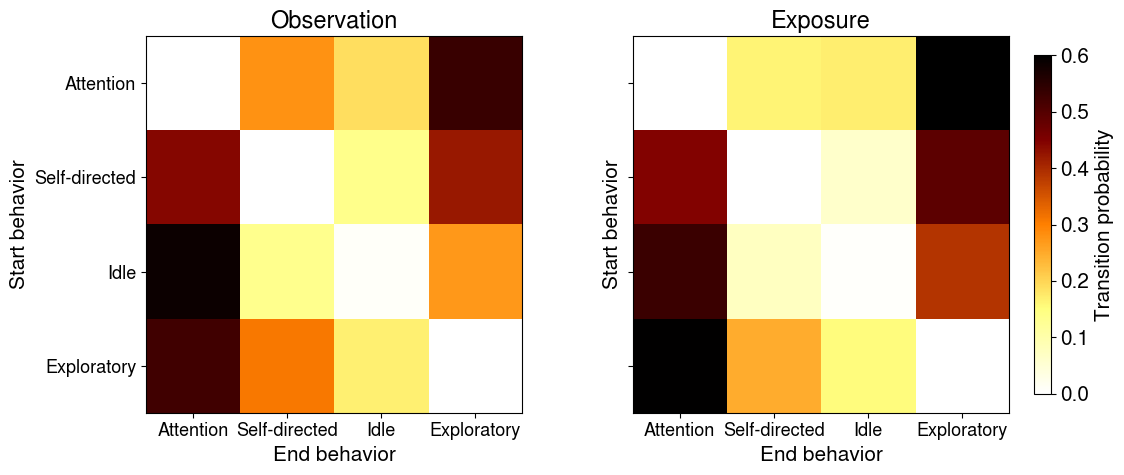

In [ ]:
fig, axs = plt.subplots(1, 2, figsize = (12, 5), sharex = True, sharey = True)

fontsize = 13
cat_values = [categories_label_dict[i] for i in range(1, 5)]
f0 = axs[0].imshow(mean_transition_mtx_obs, cmap = "afmhot_r", vmin = 0, vmax = .6)
f1 = axs[1].imshow(mean_transition_mtx_xpo, cmap = "afmhot_r", vmin = 0, vmax = .6)

plt.colorbar(f1, ax = axs[1], shrink = .9, label = "Transition probability")


for i in range(2):
    axs[i].set_xticks(np.arange(len(cat_values)), cat_values, fontsize = fontsize)
    axs[i].set_yticks(np.arange(len(cat_values)), cat_values, fontsize = fontsize)
    axs[i].set_xlabel("End behavior", fontsize = fontsize + 2)
    axs[i].set_ylabel("Start behavior", fontsize = fontsize + 2)

axs[0].set_title("Observation", fontsize = fontsize + 4)
axs[1].set_title("Exposure", fontsize = fontsize + 4)

plt.tight_layout()

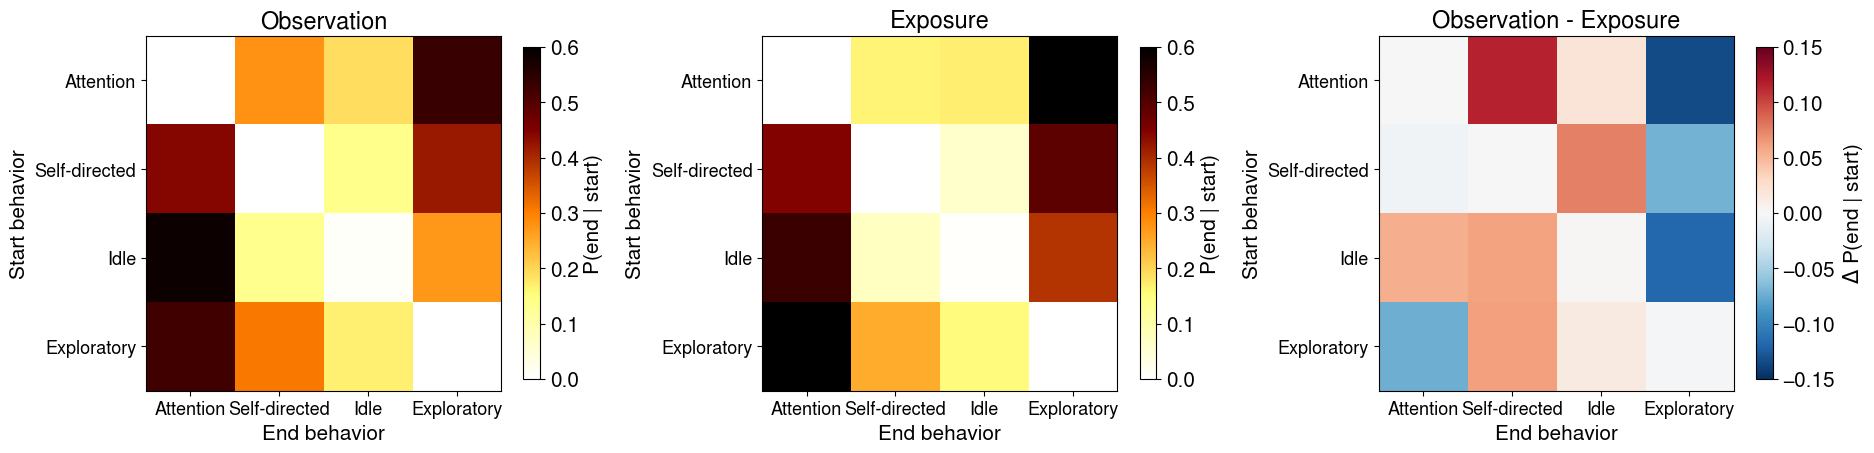

In [ ]:
fig, axs = plt.subplots(1, 3, figsize = (19, 5), sharex = True)

fontsize = 13
cat_values = [categories_label_dict[i] for i in range(1, 5)]
f0 = axs[0].imshow(mean_transition_mtx_obs, cmap = "afmhot_r", vmin = 0, vmax = .6)
f1 = axs[1].imshow(mean_transition_mtx_xpo, cmap = "afmhot_r", vmin = 0, vmax = .6)
f2 = axs[2].imshow(mean_transition_mtx_obs - mean_transition_mtx_xpo, cmap = "RdBu_r", vmin = -.15, vmax = .15)


plt.colorbar(f0, ax = axs[0], shrink = .8, label = "P(end | start)")
plt.colorbar(f1, ax = axs[1], shrink = .8, label = "P(end | start)")
plt.colorbar(f2, ax = axs[2], shrink = .8, label = r"$\Delta$ P(end | start)")


for i in range(3):
    axs[i].set_xticks(np.arange(len(cat_values)), cat_values, fontsize = fontsize)
    axs[i].set_yticks(np.arange(len(cat_values)), cat_values, fontsize = fontsize)
    axs[i].set_xlabel("End behavior", fontsize = fontsize + 2)
    axs[i].set_ylabel("Start behavior", fontsize = fontsize + 2)

axs[0].set_title("Observation", fontsize = fontsize + 4)
axs[1].set_title("Exposure", fontsize = fontsize + 4)
axs[2].set_title("Observation - Exposure", fontsize = fontsize + 4)

plt.tight_layout()
plt.savefig(os.path.join(fig_pub_path, "behavioral_categories_transition_prob_diff.svg"), format="svg")

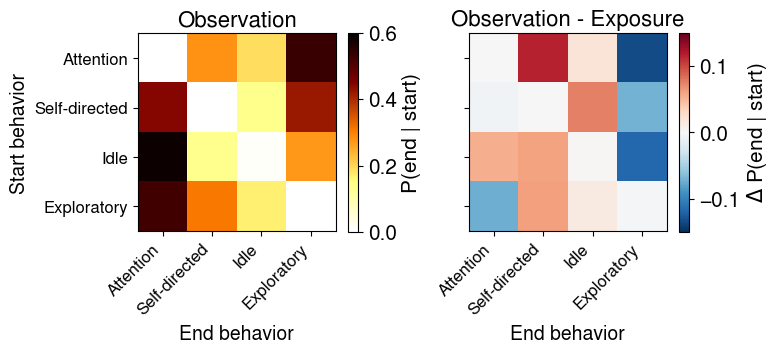

In [ ]:
fig, axs = plt.subplots(1, 2, figsize = (8, 4), sharex = True, sharey = True)

fontsize = 12
cat_values = [categories_label_dict[i] for i in range(1, 5)]
f0 = axs[0].imshow(mean_transition_mtx_obs, cmap = "afmhot_r", vmin = 0, vmax = .6)
f1 = axs[1].imshow(mean_transition_mtx_obs - mean_transition_mtx_xpo, cmap = "RdBu_r", vmin = -.15, vmax = .15)


plt.colorbar(f0, ax = axs[0], shrink = .7, label = "P(end | start)")
plt.colorbar(f1, ax = axs[1], shrink = .7, label = r"$\Delta$ P(end | start)")

for i in range(2):
    axs[i].set_xticks(np.arange(len(cat_values)), cat_values, fontsize = fontsize, rotation = 45, ha = "right")
    axs[i].set_yticks(np.arange(len(cat_values)), cat_values, fontsize = fontsize)
    axs[i].set_xlabel("End behavior", fontsize = fontsize + 2)
axs[0].set_ylabel("Start behavior", fontsize = fontsize + 2)

axs[0].set_title("Observation", fontsize = fontsize + 4)
axs[1].set_title("Observation - Exposure", fontsize = fontsize + 4)

plt.tight_layout()
# plt.savefig(os.path.join(fig_pub_path, "behavioral_categories_transition_prob_diff.svg"), format="svg")

In [9]:
from itertools import combinations

def permutation_test_transition_matrices(
    X: np.ndarray,
    y: np.ndarray,
    n_permutations: int = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Permutation test for group differences in transition matrices.
    
    Parameters
    ----------
    X : np.ndarray
        Transition matrices, shape (n_animals, 4, 4).
    y : np.ndarray
        Group labels, shape (n_animals,).
    n_permutations : int, optional
        Number of permutations. If None, uses exact test (all permutations).
        
    Returns
    -------
    diff_obs : np.ndarray
        Observed difference matrix (Group 0 - Group 1), shape (4, 4).
    p_values : np.ndarray
        Two-tailed p-values per cell, shape (4, 4).
    """
    n_animals = len(y)
    n_group1 = int(y.sum())
    
    # Observed difference
    T0_obs = X[y == 0].mean(axis=0)
    T1_obs = X[y == 1].mean(axis=0)
    diff_obs = T0_obs - T1_obs
    
    # Determine permutations
    if n_permutations is None or n_permutations >= len(list(combinations(range(n_animals), n_group1))):
        # Exact test: enumerate all combinations
        group1_indices_list = list(combinations(range(n_animals), n_group1))
        exact = True
    else:
        # Monte Carlo: random permutations
        rng = np.random.default_rng(42)
        group1_indices_list = [
            tuple(rng.choice(n_animals, size=n_group1, replace=False))
            for _ in range(n_permutations)
        ]
        exact = False
    
    # Count extreme values
    count_extreme = np.zeros((4, 4))
    
    for group1_indices in group1_indices_list:
        y_perm = np.zeros(n_animals)
        y_perm[list(group1_indices)] = 1
        
        T0_perm = X[y_perm == 0].mean(axis=0)
        T1_perm = X[y_perm == 1].mean(axis=0)
        diff_perm = T0_perm - T1_perm
        
        # Two-tailed: count where |perm| >= |obs|
        count_extreme += (np.abs(diff_perm) >= np.abs(diff_obs)).astype(float)
    
    n_total = len(group1_indices_list)
    p_values = count_extreme / n_total
    
    print(f"Permutation test: {n_total} permutations ({'exact' if exact else 'Monte Carlo'})")
    
    return diff_obs, p_values

In [10]:
X_transitions = np.concatenate([mean_transition_mtx_per_animal_obs, mean_transition_mtx_per_animal_xpo])
y = np.concatenate([np.zeros(mean_transition_mtx_per_animal_obs.shape[0]), np.ones(mean_transition_mtx_per_animal_xpo.shape[0])])

diff_obs, p_values = permutation_test_transition_matrices(X_transitions, y)

Permutation test: 2002 permutations (exact)


In [11]:
def plot_transition_difference(
    diff: np.ndarray,
    p_values: np.ndarray,
    state_labels: list[str] = None,
    alpha: float = 0.05,
    ax: plt.Axes = None,
    cmap: str = 'RdBu_r',
    title: str = 'Transition Probability Difference (G0 - G1)',
) -> plt.Axes:
    """
    Plot transition matrix difference with significance annotations.
    
    Parameters
    ----------
    diff : np.ndarray
        Difference matrix, shape (4, 4).
    p_values : np.ndarray
        P-value matrix, shape (4, 4).
    state_labels : list[str], optional
        Labels for states.
    alpha : float
        Significance threshold.
    ax : plt.Axes, optional
        Axes to plot on.
    cmap : str
        Colormap (diverging recommended).
    title : str
        Plot title.
        
    Returns
    -------
    ax : plt.Axes
    """
    n_states = diff.shape[0]
    
    if state_labels is None:
        state_labels = [f'S{i}' for i in range(n_states)]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    
    # Symmetric color limits
    vlim = np.abs(diff).max()
    
    im = ax.imshow(diff, cmap=cmap, vmin=-vlim, vmax=vlim)
    
    # Annotations
    for i in range(n_states):
        for j in range(n_states):
            if i == j:
                # Diagonal: no transition
                ax.text(j, i, '-', ha='center', va='center', fontsize=10, color='gray')
            else:
                # Value and significance
                val = diff[i, j]
                p = p_values[i, j]
                
                if p < 0.001:
                    sig = '***'
                elif p < 0.01:
                    sig = '**'
                elif p < alpha:
                    sig = '*'
                else:
                    sig = ''
                
                text = f'{sig}'
                color = 'white' if np.abs(val) > vlim * 0.6 else 'black'
                ax.text(j, i, text, ha='center', va='center', fontsize=30, color=color)
    
    # Labels
    ax.set_xticks(range(n_states))
    ax.set_yticks(range(n_states))
    ax.set_xticklabels(state_labels)
    ax.set_yticklabels(state_labels)
    ax.set_xlabel('To')
    ax.set_ylabel('From')
    ax.set_title(title)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Δ Probability')
    
    return ax

<Axes: title={'center': 'Transition Probability Difference (G0 - G1)'}, xlabel='To', ylabel='From'>

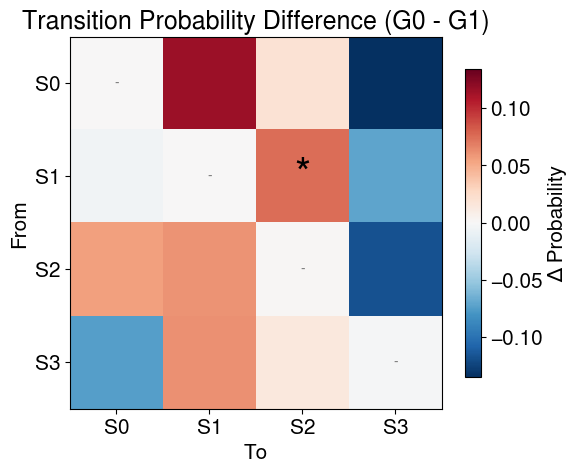

In [12]:
diff_mtx = mean_transition_mtx_obs - mean_transition_mtx_xpo
plot_transition_difference(diff_mtx, p_values)

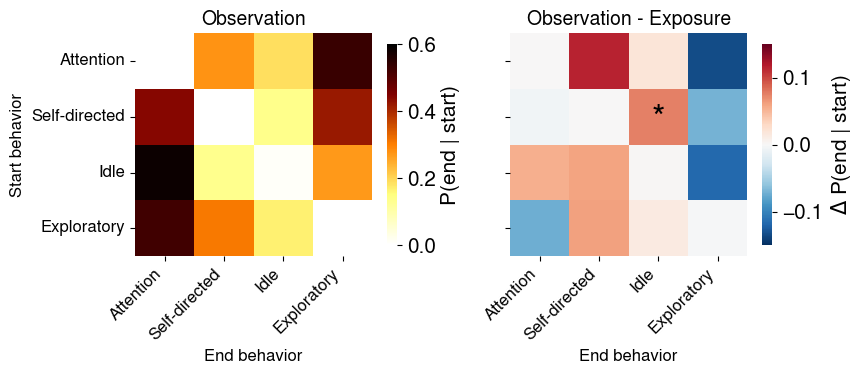

In [65]:
fig, axs = plt.subplots(1, 2, figsize = (9, 4), sharex = True, sharey = True)

fontsize = 10
cat_values = [categories_label[i] for i in range(1, 5)]

annot_matrix = np.full((len(cat_values), len(cat_values)), '', dtype=object)
for i in range(len(cat_values)):
    for j in range(len(cat_values)):
        if i != j:  # Skip diagonal
            p = p_values[i, j]
            if p < 0.001:
                annot_matrix[i, j] = '***'
            elif p < 0.01:
                annot_matrix[i, j] = '**'
            elif p < 0.05:
                annot_matrix[i, j] = '*'


sns.heatmap(mean_transition_mtx_obs, cmap = "afmhot_r", vmin = 0, vmax = .6, ax=axs[0], 
            xticklabels=cat_values, yticklabels=cat_values,
            cbar_kws={'label': r"P(end | start)", 'shrink': 0.9})
axs[0].tick_params(axis='x', rotation=45, labelsize=fontsize + 2)
axs[0].tick_params(axis='y', labelsize=fontsize + 2)
axs[0].set_xticklabels(axs[0].get_xticklabels(), ha="right")
axs[0].set_xlabel("End behavior", fontsize=fontsize + 2)
axs[0].set_ylabel("Start behavior", fontsize=fontsize + 2)

obs_xpo_diff = mean_transition_mtx_obs - mean_transition_mtx_xpo
sns.heatmap(obs_xpo_diff, 
            cmap="RdBu_r", vmin=-.15, vmax=.15, 
            annot=annot_matrix, fmt='', 
            annot_kws={'fontsize': fontsize + 15, 'color': 'black', 'va': 'center_baseline'},
            cbar_kws={'label': r"$\Delta$ P(end | start)", 'shrink': 0.9},
            xticklabels=cat_values, yticklabels=cat_values,
            ax=axs[1])
axs[1].tick_params(axis='x', rotation=45, labelsize=fontsize + 2)
axs[1].tick_params(axis='y', labelsize=fontsize + 2)
axs[1].set_xticklabels(axs[1].get_xticklabels(), ha="right")
axs[1].set_xlabel("End behavior", fontsize=fontsize + 2)

# plt.colorbar(f0, ax = axs[0], shrink = .7, label = "P(end | start)")
# plt.colorbar(f1, ax = axs[1], shrink = .7, label = r"$\Delta$ P(end | start)")

for i in range(2):
    axs[i].set_xlabel("End behavior", fontsize = fontsize + 2)
axs[0].set_ylabel("Start behavior", fontsize = fontsize + 2)

axs[0].set_title("Observation", fontsize = fontsize + 4)
axs[1].set_title("Observation - Exposure", fontsize = fontsize + 4)

plt.tight_layout()
plt.savefig(os.path.join(fig_pub_path, "behavioral_categories_transition_prob_diff.svg"), format="svg")